# Exploratory Data Analysis — House Price Dataset

This notebook explores the raw `data/house_prices.csv` dataset (300 property
records, 8 columns) to understand distributions, relationships, and data
quality before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/house_prices.csv')
df.shape

(300, 8)

## Data dictionary

| Column | Type | Description |
|---|---|---|
| Property_ID | string | Unique identifier for the listing |
| Area | int | Floor area in square feet |
| Bedrooms | int | Number of bedrooms |
| Bathrooms | int | Number of bathrooms |
| Age | int | Age of the property in years |
| Location | categorical | City Center / Suburb / Rural |
| Property_Type | categorical | House / Apartment / Villa |
| Price | int | Sale price in INR (target variable) |

In [2]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Property_ID    300 non-null    str  
 1   Area           300 non-null    int64
 2   Bedrooms       300 non-null    int64
 3   Bathrooms      300 non-null    int64
 4   Age            300 non-null    int64
 5   Location       300 non-null    str  
 6   Property_Type  300 non-null    str  
 7   Price          300 non-null    int64
dtypes: int64(5), str(3)
memory usage: 18.9 KB


Property_ID      0
Area             0
Bedrooms         0
Bathrooms        0
Age              0
Location         0
Property_Type    0
Price            0
dtype: int64

In [3]:
df.describe()

,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


No missing values and no obvious data quality issues in this sample — the cleaning pipeline in `src/data_preprocessing.py` still guards against duplicates, impossible values, and unseen categories in case new data is messier.

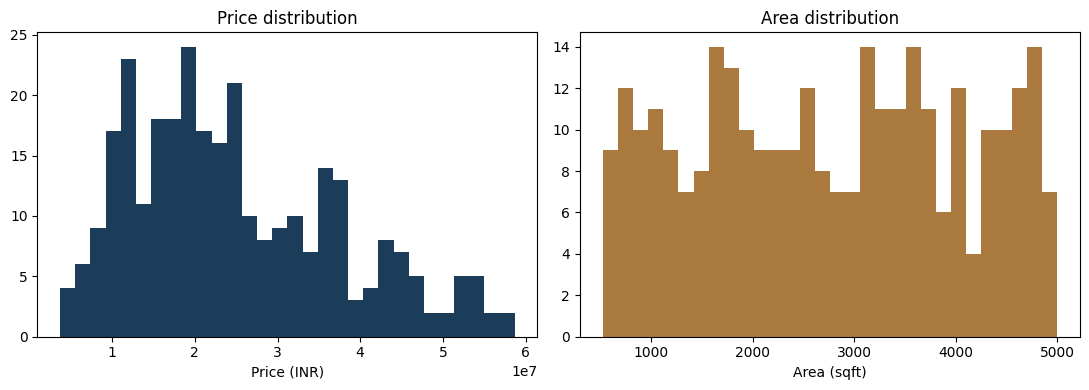

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].hist(df['Price'], bins=30, color='#1C3D5A')
axes[0].set_title('Price distribution')
axes[0].set_xlabel('Price (INR)')

axes[1].hist(df['Area'], bins=30, color='#A9793E')
axes[1].set_title('Area distribution')
axes[1].set_xlabel('Area (sqft)')
plt.tight_layout()
plt.show()

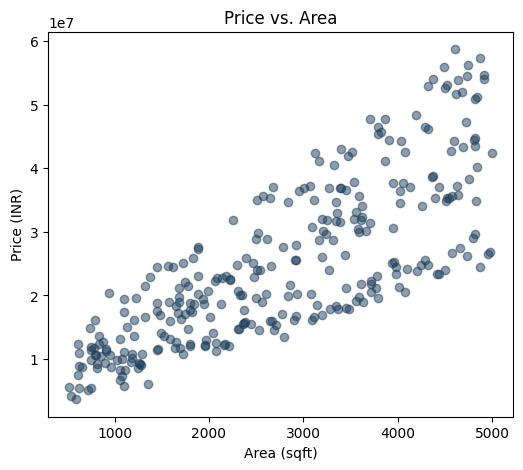

,Area,Price
Area,1.000000,0.796287
Price,0.796287,1.000000


In [5]:
plt.figure(figsize=(6,5))
plt.scatter(df['Area'], df['Price'], alpha=0.5, color='#1C3D5A')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (INR)')
plt.title('Price vs. Area')
plt.show()

df[['Area','Price']].corr()

Area shows a strong positive linear relationship with price, consistent with it later emerging as the dominant feature in the trained models.

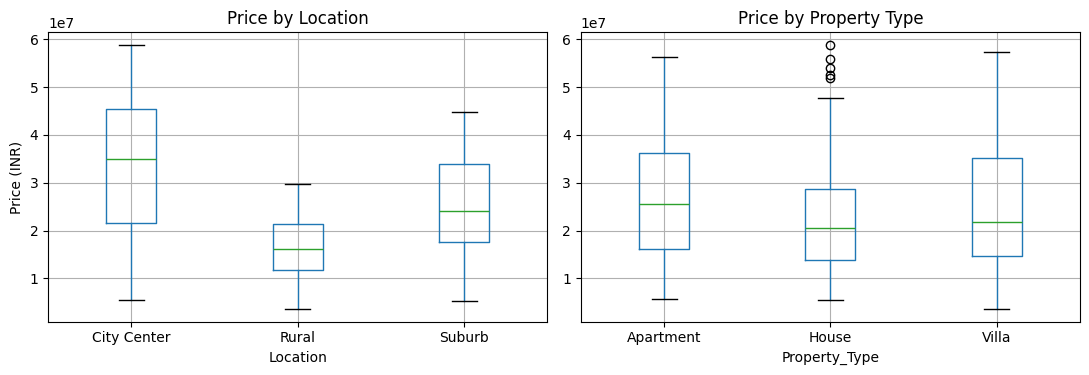

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
df.boxplot(column='Price', by='Location', ax=axes[0])
axes[0].set_title('Price by Location')
axes[0].set_ylabel('Price (INR)')
plt.suptitle('')

df.boxplot(column='Price', by='Property_Type', ax=axes[1])
axes[1].set_title('Price by Property Type')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [7]:
df.groupby('Location')['Price'].mean().sort_values(ascending=False)

Location
City Center    3.314979e+07
Suburb         2.510807e+07
Rural          1.646143e+07
Name: Price, dtype: float64

City Center commands a clear price premium over Suburb and Rural locations — this shows up later as the second-most important feature after Area.

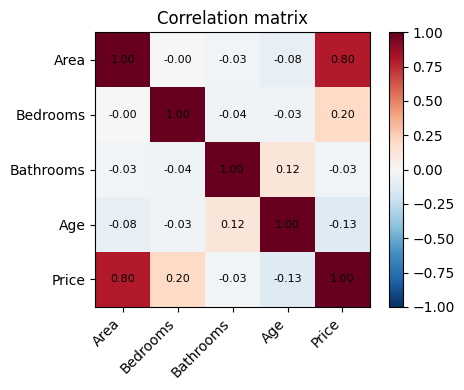

In [8]:
corr_cols = ['Area','Bedrooms','Bathrooms','Age','Price']
corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

## Takeaways for modeling

- **Area** is the strongest numeric predictor of price.
- **Age** correlates negatively with price, as expected (depreciation).
- **Bedrooms/Bathrooms** correlate with price but less strongly than Area.
- **Location** and **Property_Type** are categorical and need encoding — a
  clear price gap exists between locations, so this is worth keeping as a
  feature rather than dropping it.
- No missing values in this sample, but the production pipeline still
  handles them defensively for future data batches.

These observations directly motivated the engineered features
(`total_rooms`, `bath_bed_ratio`, `is_new`, `area_per_room`, `age_bucket`)
added in `src/data_preprocessing.py`.